In [1]:
import pandas as pd

df = pd.read_csv('../data/kaggleV2-May-2016.csv')

print("Rows, columns:", df.shape)
df.head()

Rows, columns: (110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [2]:
# Column names, data types, and non-null counts
df.info()

# Count of missing values per column
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 17.6 MB

Missing values per column:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay     

In [3]:
# Distribution of target variable
print("No-show counts:")
print(df['No-show'].value_counts())
print("\nNo-show rate:")
print(df['No-show'].value_counts(normalize=True))

# Summary statistics for numeric columns - checking for impossible values
df.describe()

No-show counts:
No-show
No     88208
Yes    22319
Name: count, dtype: int64

No-show rate:
No-show
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64


,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [4]:
# Converts data columns from text to datetime
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Strips the time component so both dates compare at day level
# ScheduledDay has a real timestamp; AppointmentDay is always midnight
sched_date = df['ScheduledDay'].dt.normalize()
appt_date = df['AppointmentDay'].dt.normalize()

# Lead time = days between scheduling and appointment
df['LeadTime'] = (appt_date - sched_date).dt.days

# Checks the result
print("Lead time summary:")
print(df['LeadTime'].describe())

Lead time summary:
count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: LeadTime, dtype: float64


In [5]:
# Counts records with impossible values
neg_age = (df['Age'] < 0).sum()
neg_lead = (df['LeadTime'] < 0).sum()

print("Records with negative age:", neg_age)
print("Records with negative lead time:", neg_lead)

# What share of the dataset is affected
print("\nPercent of total:")
print("Negative age:", round(neg_age / len(df) * 100, 4), "%")
print("Negative lead time:", round(neg_lead / len(df) * 100, 4), "%")

# Looks at the very old records before deciding on them
print("\nAges above 100:")
print(df[df['Age'] > 100]['Age'].value_counts().sort_index())

Records with negative age: 1
Records with negative lead time: 5

Percent of total:
Negative age: 0.0009 %
Negative lead time: 0.0045 %

Ages above 100:
Age
102    2
115    5
Name: count, dtype: int64


In [6]:
# Records starting count for documentation
rows_before = len(df)

# Removes impossible and implausible records
df_clean = df[
    (df['Age'] >= 0) &          # negative age is impossible
    (df['Age'] <= 100) &        # cluster at 115 looks like a data artifact
    (df['LeadTime'] >= 0)       # appointment cannot precede scheduling
].copy()

# Converts lead time to whole days
df_clean['LeadTime'] = df_clean['LeadTime'].astype(int)

# Recodes target: "Yes" in No-show means the patient did NOT attend
df_clean['NoShow'] = (df_clean['No-show'] == 'Yes').astype(int)

# Reports what was removed
rows_after = len(df_clean)
print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Rows removed:", rows_before - rows_after)
print("\nNo-show rate after cleaning:", round(df_clean['NoShow'].mean(), 4))

Rows before cleaning: 110527
Rows after cleaning: 110514
Rows removed: 13

No-show rate after cleaning: 0.2019


In [7]:
# Compares lead time between patients who attended and those who missed
print("Lead time by attendance outcome:")
print(df_clean.groupby('NoShow')['LeadTime'].describe())

# Mean lead time for each group
attended = df_clean[df_clean['NoShow'] == 0]['LeadTime']
missed = df_clean[df_clean['NoShow'] == 1]['LeadTime']

print("\nMean lead time, attended:", round(attended.mean(), 2), "days")
print("Mean lead time, missed:", round(missed.mean(), 2), "days")
print("Difference:", round(missed.mean() - attended.mean(), 2), "days")

Lead time by attendance outcome:
          count       mean        std  min  25%   50%   75%    max
NoShow                                                            
0       88203.0   8.754963  14.550688  0.0  0.0   2.0  12.0  179.0
1       22311.0  15.835642  16.605608  0.0  4.0  11.0  23.0  179.0

Mean lead time, attended: 8.75 days
Mean lead time, missed: 15.84 days
Difference: 7.08 days


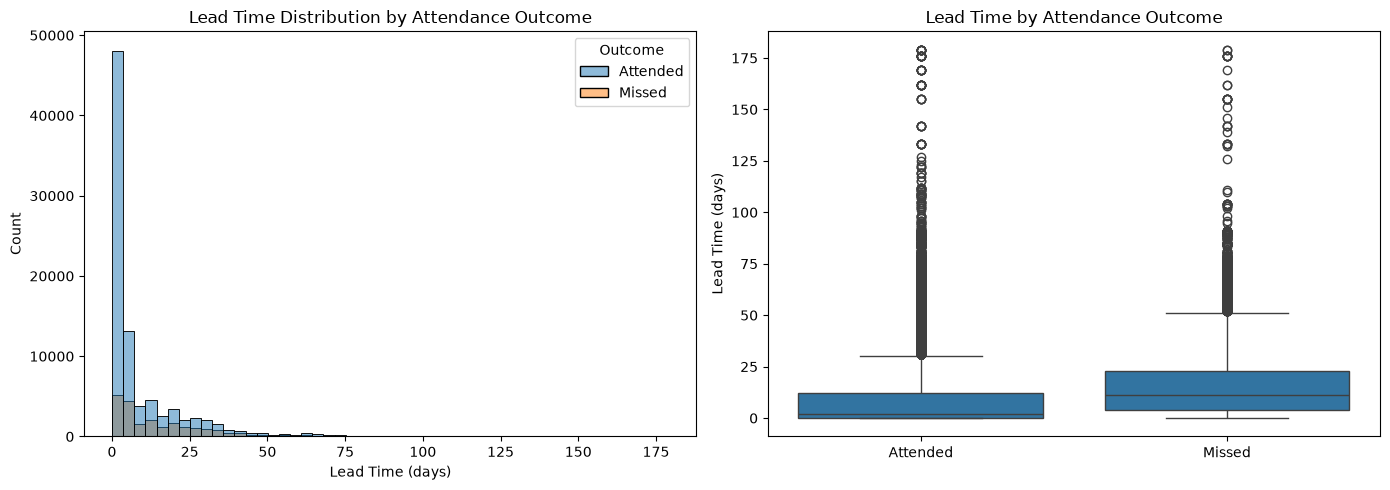

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Readable labels for plotting (keeps numeric NoShow intact for modeling)
df_clean['Outcome'] = df_clean['NoShow'].map({0: 'Attended', 1: 'Missed'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of lead time by outcome
sns.histplot(data=df_clean, x='LeadTime', hue='Outcome', bins=50, ax=axes[0])
axes[0].set_title('Lead Time Distribution by Attendance Outcome')
axes[0].set_xlabel('Lead Time (days)')

# Right: boxplot comparing the two groups
sns.boxplot(data=df_clean, x='Outcome', y='LeadTime', ax=axes[1])
axes[1].set_title('Lead Time by Attendance Outcome')
axes[1].set_xlabel('')
axes[1].set_ylabel('Lead Time (days)')

plt.tight_layout()
plt.show()

In [9]:
from scipy import stats
import numpy as np

# 1. Test the normality assumption
# Shapiro-Wilk is limited to 5000 observations, so test a random sample
np.random.seed(42)
sample_attended = attended.sample(5000, random_state=42)
sample_missed = missed.sample(5000, random_state=42)

shapiro_attended = stats.shapiro(sample_attended)
shapiro_missed = stats.shapiro(sample_missed)

print("Shapiro-Wilk normality test (n=5000 sample each):")
print("Attended  — statistic:", round(shapiro_attended.statistic, 4), " p-value:", shapiro_attended.pvalue)
print("Missed    — statistic:", round(shapiro_missed.statistic, 4), " p-value:", shapiro_missed.pvalue)

# 2. Welch's t-test — does not assume equal variances between groups
t_stat, t_p = stats.ttest_ind(missed, attended, equal_var=False)
print("\nWelch's two-sample t-test:")
print("t-statistic:", round(t_stat, 4))
print("p-value:", t_p)

# 3. Mann-Whitney U — nonparametric confirmation, no normality assumption
u_stat, u_p = stats.mannwhitneyu(missed, attended, alternative='greater')
print("\nMann-Whitney U test:")
print("U-statistic:", u_stat)
print("p-value:", u_p)

Shapiro-Wilk normality test (n=5000 sample each):
Attended  — statistic: 0.6697  p-value: 1.9226258556213416e-71
Missed    — statistic: 0.8326  p-value: 2.800582129704384e-58

Welch's two-sample t-test:
t-statistic: 58.2824
p-value: 0.0

Mann-Whitney U test:
U-statistic: 1374117323.5
p-value: 0.0


In [10]:
# Cohen's d — standardized effect size for the difference in means
# Needed because with n=110,000 almost any difference is statistically significant
n1, n2 = len(missed), len(attended)
var1, var2 = missed.var(ddof=1), attended.var(ddof=1)

# Pooled standard deviation
pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

cohens_d = (missed.mean() - attended.mean()) / pooled_sd

print("Cohen's d:", round(cohens_d, 4))
print("\nReference: 0.2 = small, 0.5 = medium, 0.8 = large")
print("Median lead time — attended:", attended.median(), "days")
print("Median lead time — missed:", missed.median(), "days")

Cohen's d: 0.4724

Reference: 0.2 = small, 0.5 = medium, 0.8 = large
Median lead time — attended: 2.0 days
Median lead time — missed: 11.0 days


In [11]:
# Sorts by patient and appointment date so history accumulates in time order
df_clean = df_clean.sort_values(['PatientId', 'AppointmentDay']).copy()

# Counts each patient's PRIOR no-shows only
# cumsum() totals past values; shift(1) excludes the current appointment
df_clean['PriorNoShows'] = (
    df_clean.groupby('PatientId')['NoShow']
    .apply(lambda s: s.shift(1).cumsum())
    .reset_index(level=0, drop=True)
)

# First appointment for each patient has no history — fill with 0
df_clean['PriorNoShows'] = df_clean['PriorNoShows'].fillna(0).astype(int)

# Verify: distribution of prior no-show counts
print("Prior no-show counts:")
print(df_clean['PriorNoShows'].value_counts().sort_index().head(10))
print("\nNo-show rate by prior no-show count:")
print(df_clean.groupby('PriorNoShows')['NoShow'].mean().head(6))

Prior no-show counts:
PriorNoShows
0    94905
1    11596
2     2590
3      791
4      296
5      143
6       69
7       33
8       30
9       20
Name: count, dtype: int64

No-show rate by prior no-show count:
PriorNoShows
0    0.186081
1    0.277854
2    0.311583
3    0.369153
4    0.439189
5    0.503497
Name: NoShow, dtype: float64


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Predictors and target
features = ['LeadTime', 'Age', 'SMS_received', 'PriorNoShows']
X = df_clean[features]
y = df_clean['NoShow']

# 80/20 split, stratified so both sets keep the same no-show rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape[0], "rows")
print("Test set:", X_test.shape[0], "rows")
print("No-show rate — train:", round(y_train.mean(), 4))
print("No-show rate — test:", round(y_test.mean(), 4))

# Fit logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("\nModel fitted.")

Training set: 88411 rows
Test set: 22103 rows
No-show rate — train: 0.2019
No-show rate — test: 0.2019

Model fitted.


In [13]:
import pandas as pd

# Coefficients as odds ratios — easier to interpret than raw log-odds
coefs = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0],
    'OddsRatio': np.exp(model.coef_[0])
})

print("Model coefficients:")
print(coefs.to_string(index=False))
print("\nIntercept:", round(model.intercept_[0], 4))

Model coefficients:
     Feature  Coefficient  OddsRatio
    LeadTime     0.023747   1.024032
         Age    -0.007753   0.992277
SMS_received     0.367872   1.444658
PriorNoShows     0.378214   1.459675

Intercept: -1.6004


In [14]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Predicted classes at the default 0.5 threshold
y_pred = model.predict(X_test)

# Predicted probabilities — needed for AUC and for threshold tuning
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall:   ", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1 score: ", round(f1_score(y_test, y_pred, zero_division=0), 4))
print("AUC-ROC:  ", round(roc_auc_score(y_test, y_prob), 4))

# Baseline for comparison: predicting "attends" for every appointment
print("\nBaseline accuracy (always predict attends):", round(1 - y_test.mean(), 4))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("Rows = actual (0=attended, 1=missed), Columns = predicted")

print("\nFull report:")
print(classification_report(y_test, y_pred, target_names=['Attended', 'Missed'], zero_division=0))

Accuracy:  0.7958
Precision: 0.427
Recall:    0.0341
F1 score:  0.0631
AUC-ROC:   0.6705

Baseline accuracy (always predict attends): 0.7981

Confusion matrix:
[[17437   204]
 [ 4310   152]]
Rows = actual (0=attended, 1=missed), Columns = predicted

Full report:
              precision    recall  f1-score   support

    Attended       0.80      0.99      0.89     17641
      Missed       0.43      0.03      0.06      4462

    accuracy                           0.80     22103
   macro avg       0.61      0.51      0.47     22103
weighted avg       0.73      0.80      0.72     22103



In [15]:
# The 0.5 threshold is arbitrary. A scheduler works down a ranked list,
# so evaluate the model by how well it concentrates no-shows at the top.

test_results = pd.DataFrame({
    'actual': y_test.values,
    'prob': y_prob
}).sort_values('prob', ascending=False)

base_rate = y_test.mean()
print("Base no-show rate:", round(base_rate, 4))
print()

# No-show rate within the highest-risk N% of appointments
for pct in [0.05, 0.10, 0.20, 0.30]:
    n = int(len(test_results) * pct)
    top = test_results.head(n)
    rate = top['actual'].mean()
    lift = rate / base_rate
    captured = top['actual'].sum() / test_results['actual'].sum()
    print(f"Top {int(pct*100):>2}% highest-risk ({n:,} appointments):")
    print(f"   no-show rate {rate:.1%}  |  lift {lift:.2f}x  |  captures {captured:.1%} of all no-shows")
    print()

# Performance at a lower decision threshold
for thresh in [0.25, 0.30, 0.35]:
    pred = (y_prob >= thresh).astype(int)
    print(f"Threshold {thresh}:  precision {precision_score(y_test, pred, zero_division=0):.3f}  "
          f"recall {recall_score(y_test, pred, zero_division=0):.3f}  "
          f"flagged {pred.sum():,}")

Base no-show rate: 0.2019

Top  5% highest-risk (1,105 appointments):
   no-show rate 36.7%  |  lift 1.82x  |  captures 9.1% of all no-shows

Top 10% highest-risk (2,210 appointments):
   no-show rate 35.8%  |  lift 1.78x  |  captures 17.7% of all no-shows

Top 20% highest-risk (4,420 appointments):
   no-show rate 34.0%  |  lift 1.68x  |  captures 33.7% of all no-shows

Top 30% highest-risk (6,630 appointments):
   no-show rate 32.4%  |  lift 1.61x  |  captures 48.2% of all no-shows

Threshold 0.25:  precision 0.335  recall 0.373  flagged 4,972
Threshold 0.3:  precision 0.348  recall 0.226  flagged 2,890
Threshold 0.35:  precision 0.368  recall 0.143  flagged 1,736


In [16]:
# Groups lead time into operational bands a scheduler would actually use
bins = [-1, 0, 3, 7, 14, 30, 60, 180]
labels = ['Same day', '1-3 days', '4-7 days', '8-14 days', '15-30 days', '31-60 days', '61+ days']

df_clean['LeadTimeBand'] = pd.cut(df_clean['LeadTime'], bins=bins, labels=labels)

# No-show rate and volume for each band
band_summary = df_clean.groupby('LeadTimeBand', observed=True).agg(
    Appointments=('NoShow', 'size'),
    NoShows=('NoShow', 'sum'),
    NoShowRate=('NoShow', 'mean')
).reset_index()

band_summary['NoShowRate'] = (band_summary['NoShowRate'] * 100).round(1)

print("No-show rate by lead time band:")
print(band_summary.to_string(index=False))

No-show rate by lead time band:
LeadTimeBand  Appointments  NoShows  NoShowRate
    Same day         38560     1792         4.6
    1-3 days         14672     3357        22.9
    4-7 days         17510     4413        25.2
   8-14 days         12025     3664        30.5
  15-30 days         17370     5661        32.6
  31-60 days          8282     2828        34.1
    61+ days          2095      596        28.4


In [17]:
from sklearn.ensemble import RandomForestClassifier

# Same train/test split, so results are directly comparable
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,          # limit depth to avoid overfitting on 88k rows
    random_state=42,
    n_jobs=-1              # use all CPU cores
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("Random Forest:")
print("  Accuracy: ", round(accuracy_score(y_test, rf_pred), 4))
print("  Precision:", round(precision_score(y_test, rf_pred, zero_division=0), 4))
print("  Recall:   ", round(recall_score(y_test, rf_pred, zero_division=0), 4))
print("  AUC-ROC:  ", round(roc_auc_score(y_test, rf_prob), 4))

print("\nLogistic Regression:")
print("  AUC-ROC:  ", round(roc_auc_score(y_test, y_prob), 4))

# Which features the forest relied on
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRandom forest feature importances:")
print(importances.to_string(index=False))

Random Forest:
  Accuracy:  0.8004
  Precision: 0.5499
  Recall:    0.063
  AUC-ROC:   0.7349

Logistic Regression:
  AUC-ROC:   0.6705

Random forest feature importances:
     Feature  Importance
    LeadTime    0.644887
         Age    0.196031
PriorNoShows    0.108678
SMS_received    0.050404


In [18]:
# Compares operational lift: which model concentrates no-shows better at the top?
def lift_table(probs, label):
    res = pd.DataFrame({'actual': y_test.values, 'prob': probs}).sort_values('prob', ascending=False)
    base = y_test.mean()
    print(f"{label}:")
    for pct in [0.05, 0.10, 0.20, 0.30]:
        n = int(len(res) * pct)
        top = res.head(n)
        rate = top['actual'].mean()
        print(f"   Top {int(pct*100):>2}%  no-show rate {rate:.1%}  |  lift {rate/base:.2f}x  |  "
              f"captures {top['actual'].sum()/res['actual'].sum():.1%} of no-shows")
    print()

lift_table(y_prob, "Logistic Regression")
lift_table(rf_prob, "Random Forest")

Logistic Regression:
   Top  5%  no-show rate 36.7%  |  lift 1.82x  |  captures 9.1% of no-shows
   Top 10%  no-show rate 35.8%  |  lift 1.78x  |  captures 17.7% of no-shows
   Top 20%  no-show rate 34.0%  |  lift 1.68x  |  captures 33.7% of no-shows
   Top 30%  no-show rate 32.4%  |  lift 1.61x  |  captures 48.2% of no-shows

Random Forest:
   Top  5%  no-show rate 49.9%  |  lift 2.47x  |  captures 12.3% of no-shows
   Top 10%  no-show rate 44.1%  |  lift 2.19x  |  captures 21.9% of no-shows
   Top 20%  no-show rate 38.2%  |  lift 1.89x  |  captures 37.8% of no-shows
   Top 30%  no-show rate 36.0%  |  lift 1.78x  |  captures 53.5% of no-shows



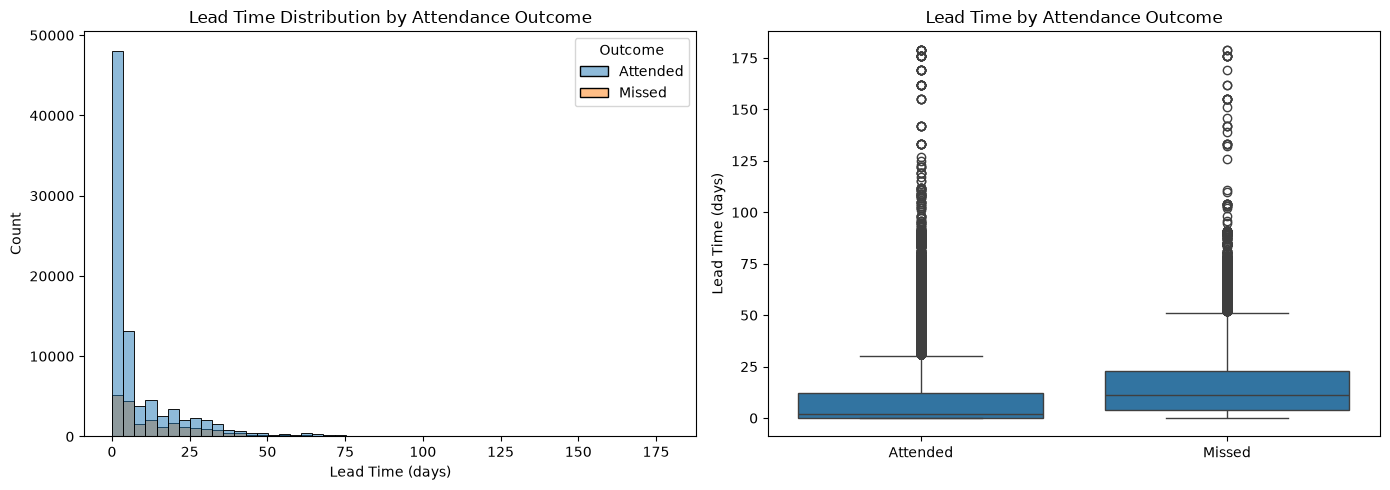

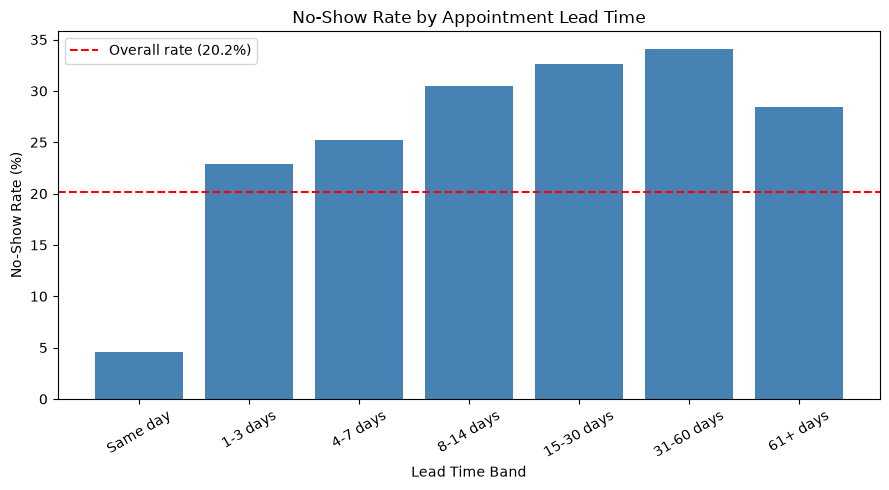

In [19]:
import os

# Creates output folders
os.makedirs('../figures', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# Figure 1: lead time distribution and boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_clean, x='LeadTime', hue='Outcome', bins=50, ax=axes[0])
axes[0].set_title('Lead Time Distribution by Attendance Outcome')
axes[0].set_xlabel('Lead Time (days)')
sns.boxplot(data=df_clean, x='Outcome', y='LeadTime', ax=axes[1])
axes[1].set_title('Lead Time by Attendance Outcome')
axes[1].set_xlabel('')
axes[1].set_ylabel('Lead Time (days)')
plt.tight_layout()
plt.savefig('../figures/fig1_leadtime_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: no-show rate by lead time band
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(band_summary['LeadTimeBand'].astype(str), band_summary['NoShowRate'], color='steelblue')
ax.set_title('No-Show Rate by Appointment Lead Time')
ax.set_xlabel('Lead Time Band')
ax.set_ylabel('No-Show Rate (%)')
ax.axhline(20.19, color='red', linestyle='--', label='Overall rate (20.2%)')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../figures/fig2_noshow_by_band.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Exports the band summary for the dashboard
band_summary.to_csv('../outputs/noshow_by_leadtime_band.csv', index=False)

# Exports a Tableau-ready extract of the cleaned data
tableau_cols = ['AppointmentID', 'Age', 'Gender', 'LeadTime', 'LeadTimeBand',
                'SMS_received', 'PriorNoShows', 'Scholarship', 'NoShow', 'Outcome']
df_clean[tableau_cols].to_csv('../outputs/noshow_clean.csv', index=False)

# Exports model comparison results for the report
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, rf_pred)],
    'Precision': [precision_score(y_test, y_pred, zero_division=0), precision_score(y_test, rf_pred, zero_division=0)],
    'Recall': [recall_score(y_test, y_pred, zero_division=0), recall_score(y_test, rf_pred, zero_division=0)],
    'AUC': [roc_auc_score(y_test, y_prob), roc_auc_score(y_test, rf_prob)]
}).round(4)
model_comparison.to_csv('../outputs/model_comparison.csv', index=False)

print("Files saved:")
print(model_comparison.to_string(index=False))
print("\nRows exported to noshow_clean.csv:", len(df_clean))

Files saved:
              Model  Accuracy  Precision  Recall    AUC
Logistic Regression    0.7958     0.4270  0.0341 0.6705
      Random Forest    0.8004     0.5499  0.0630 0.7349

Rows exported to noshow_clean.csv: 110514


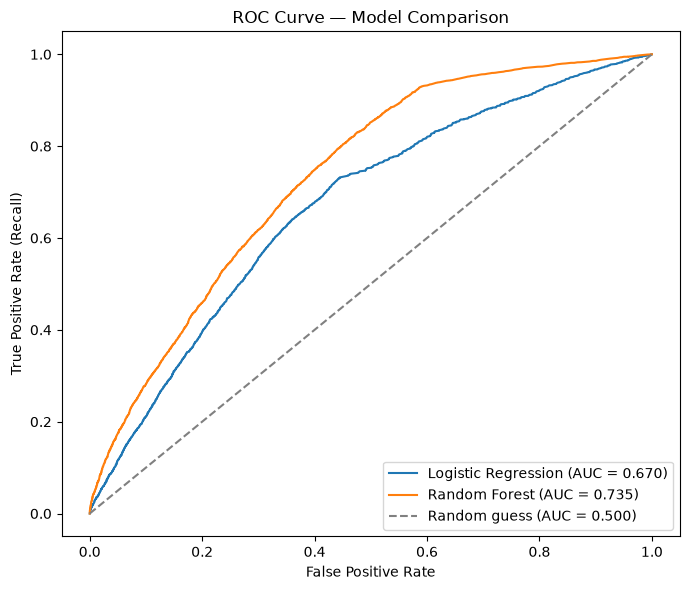

In [21]:
from sklearn.metrics import roc_curve

# ROC curve: true positive rate vs. false positive rate at every possible threshold
# Uses predicted probabilities, not yes/no predictions
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)     # logistic regression
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)    # random forest

fig, ax = plt.subplots(figsize=(7, 6))

# One curve per model, with AUC in the legend
ax.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})')
ax.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})')

# Diagonal reference line = random guessing (AUC 0.5)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.500)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Model Comparison')
ax.legend(loc='lower right')

# Save for the report and appendix
plt.tight_layout()
plt.savefig('../figures/fig3_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()